# Phishing Website Detection - reproducing and critiquing an ML tutorial

Course: Data Science in Cyber (Dr. Uri Itai), final project.

For this project I picked the blog post **"Detecting Phishing Websites using
Machine Learning"** by Sayak Paul, published under Intel Software Innovators
on Medium, with the matching GitHub repo
[`sayakpaul/Phishing-Websites-Detection`](https://github.com/sayakpaul/Phishing-Websites-Detection).
The article walks through the classic **UCI Phishing Websites** dataset
(11,055 sites, 30 already-engineered categorical features) and trains a
logistic regression baseline, a small neural net, and finally a fastai model
with entity embeddings, ending at ~97% accuracy which the author calls
"matching state of the art."

The plan here isn't just to redo what the author did. I reproduce the basic
pipeline, but I also poke at the dataset itself (turns out it has a pretty
serious duplication problem that nobody mentions), try a couple of feature
engineering ideas, and compare a handful of models the author didn't try
(mainly Random Forest and gradient boosting). The full discussion of whether
the author's claims hold up lives in the PDF report - this notebook is the
"show me the numbers" half of the project.

Random seed is fixed to 42 everywhere so the numbers below should reproduce
exactly if you re-run this.

## 1. Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)


In [2]:
def load_phishing_arff(path):
    """Parse the UCI .arff file into a plain int DataFrame.

    The file format is simple enough (one @attribute line per column, then
    a flat @data block) that pulling in a whole arff library felt like
    overkill for 31 columns.
    """
    columns, rows, in_data_block = [], [], False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("%"):
                continue
            if line.lower().startswith("@attribute"):
                columns.append(line.split()[1])
            elif line.lower().startswith("@data"):
                in_data_block = True
            elif in_data_block:
                rows.append(line.split(","))
    return pd.DataFrame(rows, columns=columns).astype(int)


df = load_phishing_arff("data/phishing_websites.arff")
df.shape


(11055, 31)

In [3]:
df.head()


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,port,HTTPS_token,Request_URL,URL_of_Anchor,Links_in_tags,SFH,Submitting_to_email,Abnormal_URL,Redirect,on_mouseover,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,1,-1,1,-1,1,-1,-1,-1,0,1,1,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,1,-1,1,0,-1,-1,1,1,0,1,1,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,1,-1,1,0,-1,-1,-1,-1,0,1,1,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,1,-1,-1,0,0,-1,1,1,0,1,1,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,1,1,1,0,0,-1,1,1,0,-1,1,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
# data size + feature types
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
print()
print(df.dtypes.value_counts())


rows: 11055, columns: 31

int64    31
Name: count, dtype: int64


All 31 columns came in as plain integers, no surprises there since the
source `.arff` declares every attribute as a small categorical set
(`{-1,1}`, `{-1,0,1}`, etc). There's nothing here that looks like a string,
a timestamp, or a float, so feature typing is basically a non-issue for this
dataset - which is a little unusual for a "real" dataset, more on that in
the feature engineering section.

**Temporal analysis.** This is one of the first red flags about the
dataset: there is no timestamp, crawl date, or "first seen" column anywhere.
Every one of the 30 predictors is a property computed from a URL/page at
some unknown point in time, and we have zero information about *when* each
site was visited. That matters a lot for a phishing problem specifically,
because phishing campaigns rotate constantly and a model trained on a
snapshot from one period can rot fast. The dataset card and the article
don't mention a collection date range either, so there's no way for us to
check this for concept drift. We just have to flag it as a real limitation
rather than analyze it away.

In [5]:
# missing values
df.isna().sum().sum()


np.int64(0)

Zero missing values anywhere, which is expected since these are all derived/computed features rather than raw scraped fields that could be absent.

In [6]:
# do the column names make sense?
print(list(df.columns))


['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


Mostly yes, these read like a sane feature list for this kind of task
(IP-in-URL, URL length, use of a shortener, SSL state, domain age, etc).
Two small things worth flagging though:

- `Domain_registeration_length` is a typo for "registration" - cosmetic, but
  it's the kind of thing that makes you wonder how carefully the dataset was
  put together overall.
- The index is just a plain RangeIndex with no site/URL identifier attached
  to each row. That's fine for modelling but it means we can never go back
  and check *which* site a given row corresponds to, or de-duplicate based on
  the actual URL - only based on the feature values, which is a weaker check
  (two different URLs can easily land on the same feature vector by chance).

In [7]:
# single-value / constant columns (would carry zero information)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
constant_cols


[]

In [8]:
# fully duplicated rows
n_dupe_rows = df.duplicated().sum()
print(f"exact duplicate rows: {n_dupe_rows} out of {len(df)} ({n_dupe_rows/len(df):.1%})")

# duplicated columns (two columns carrying identical information)
dupe_cols = df.T.duplicated()
print(f"duplicated columns: {dupe_cols.sum()}")


exact duplicate rows: 5206 out of 11055 (47.1%)
duplicated columns: 0


No constant columns and no duplicated *columns*, good. But **47% of
the rows are exact duplicates of another row** (every column identical,
including the label). That's a big number and it's not something the
original article ever brings up. I dig into this more in the EDA section
because it turns out to matter a lot for evaluating the author's accuracy
claims.

## 2. Exploratory Data Analysis

In [9]:
target_raw = df["Result"]
features = df.drop(columns=["Result"])
# recode so 1 = phishing, 0 = legitimate (more intuitive than the original -1/1 scheme)
y = target_raw.map({-1: 1, 1: 0})
y.value_counts(normalize=True).rename({0: "legitimate", 1: "phishing"})


Result
legitimate    0.556943
phishing      0.443057
Name: proportion, dtype: float64

### Class imbalance / prevalence

44.3% of the rows are labelled phishing, 55.7% legitimate. That's close
enough to balanced that none of the standard classifiers will struggle with
it, and it's clearly why the author never discusses class imbalance at all
in the article - on paper there isn't one.

But that ratio is **not** how phishing looks in the real world. Estimates
from anti-phishing services put phishing URLs at a tiny fraction of a
percent of all web traffic / URLs encountered by a browser or mail filter.
A near-50/50 training set is a deliberate sampling choice by whoever built
this dataset (PhishTank for the phishing half, a benign URL list for the
other half), not a representative sample of "the internet." It is a totally
reasonable thing to do for training a balanced classifier, but it means
accuracy and even precision numbers from this dataset don't translate
directly into "this is the false-positive rate you'd see in production."
If the true prior for phishing is, say, 1 in 10,000 URLs instead of 4 in 10,
the same recall/precision trade-off looks completely different once you run
the numbers through Bayes' rule. Neither the article nor (as far as I could
tell) the original dataset paper addresses this.

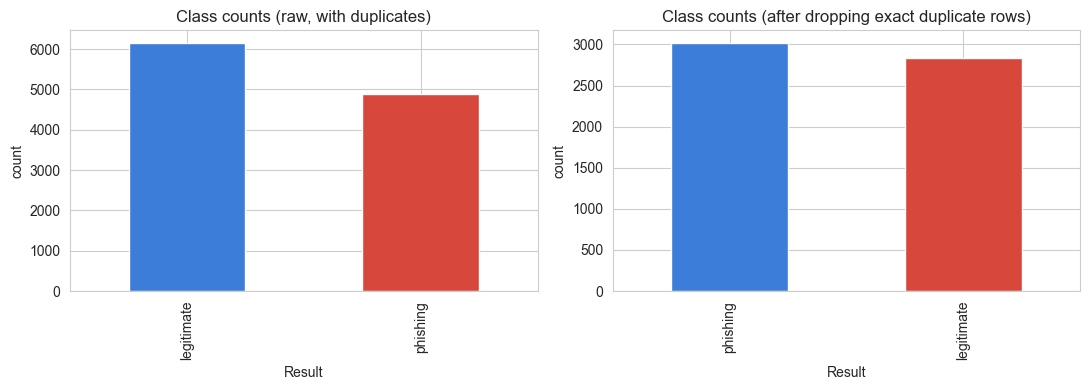

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
y.map({0: "legitimate", 1: "phishing"}).value_counts().plot(
    kind="bar", color=["#3b7dd8", "#d8473b"], ax=axes[0])
axes[0].set_title("Class counts (raw, with duplicates)")
axes[0].set_ylabel("count")

dedup_labels = df.drop_duplicates()["Result"].map({-1: "phishing", 1: "legitimate"})
dedup_labels.value_counts().plot(kind="bar", color=["#3b7dd8", "#d8473b"], ax=axes[1])
axes[1].set_title("Class counts (after dropping exact duplicate rows)")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.savefig("figures/class_balance.png", dpi=130)
plt.show()


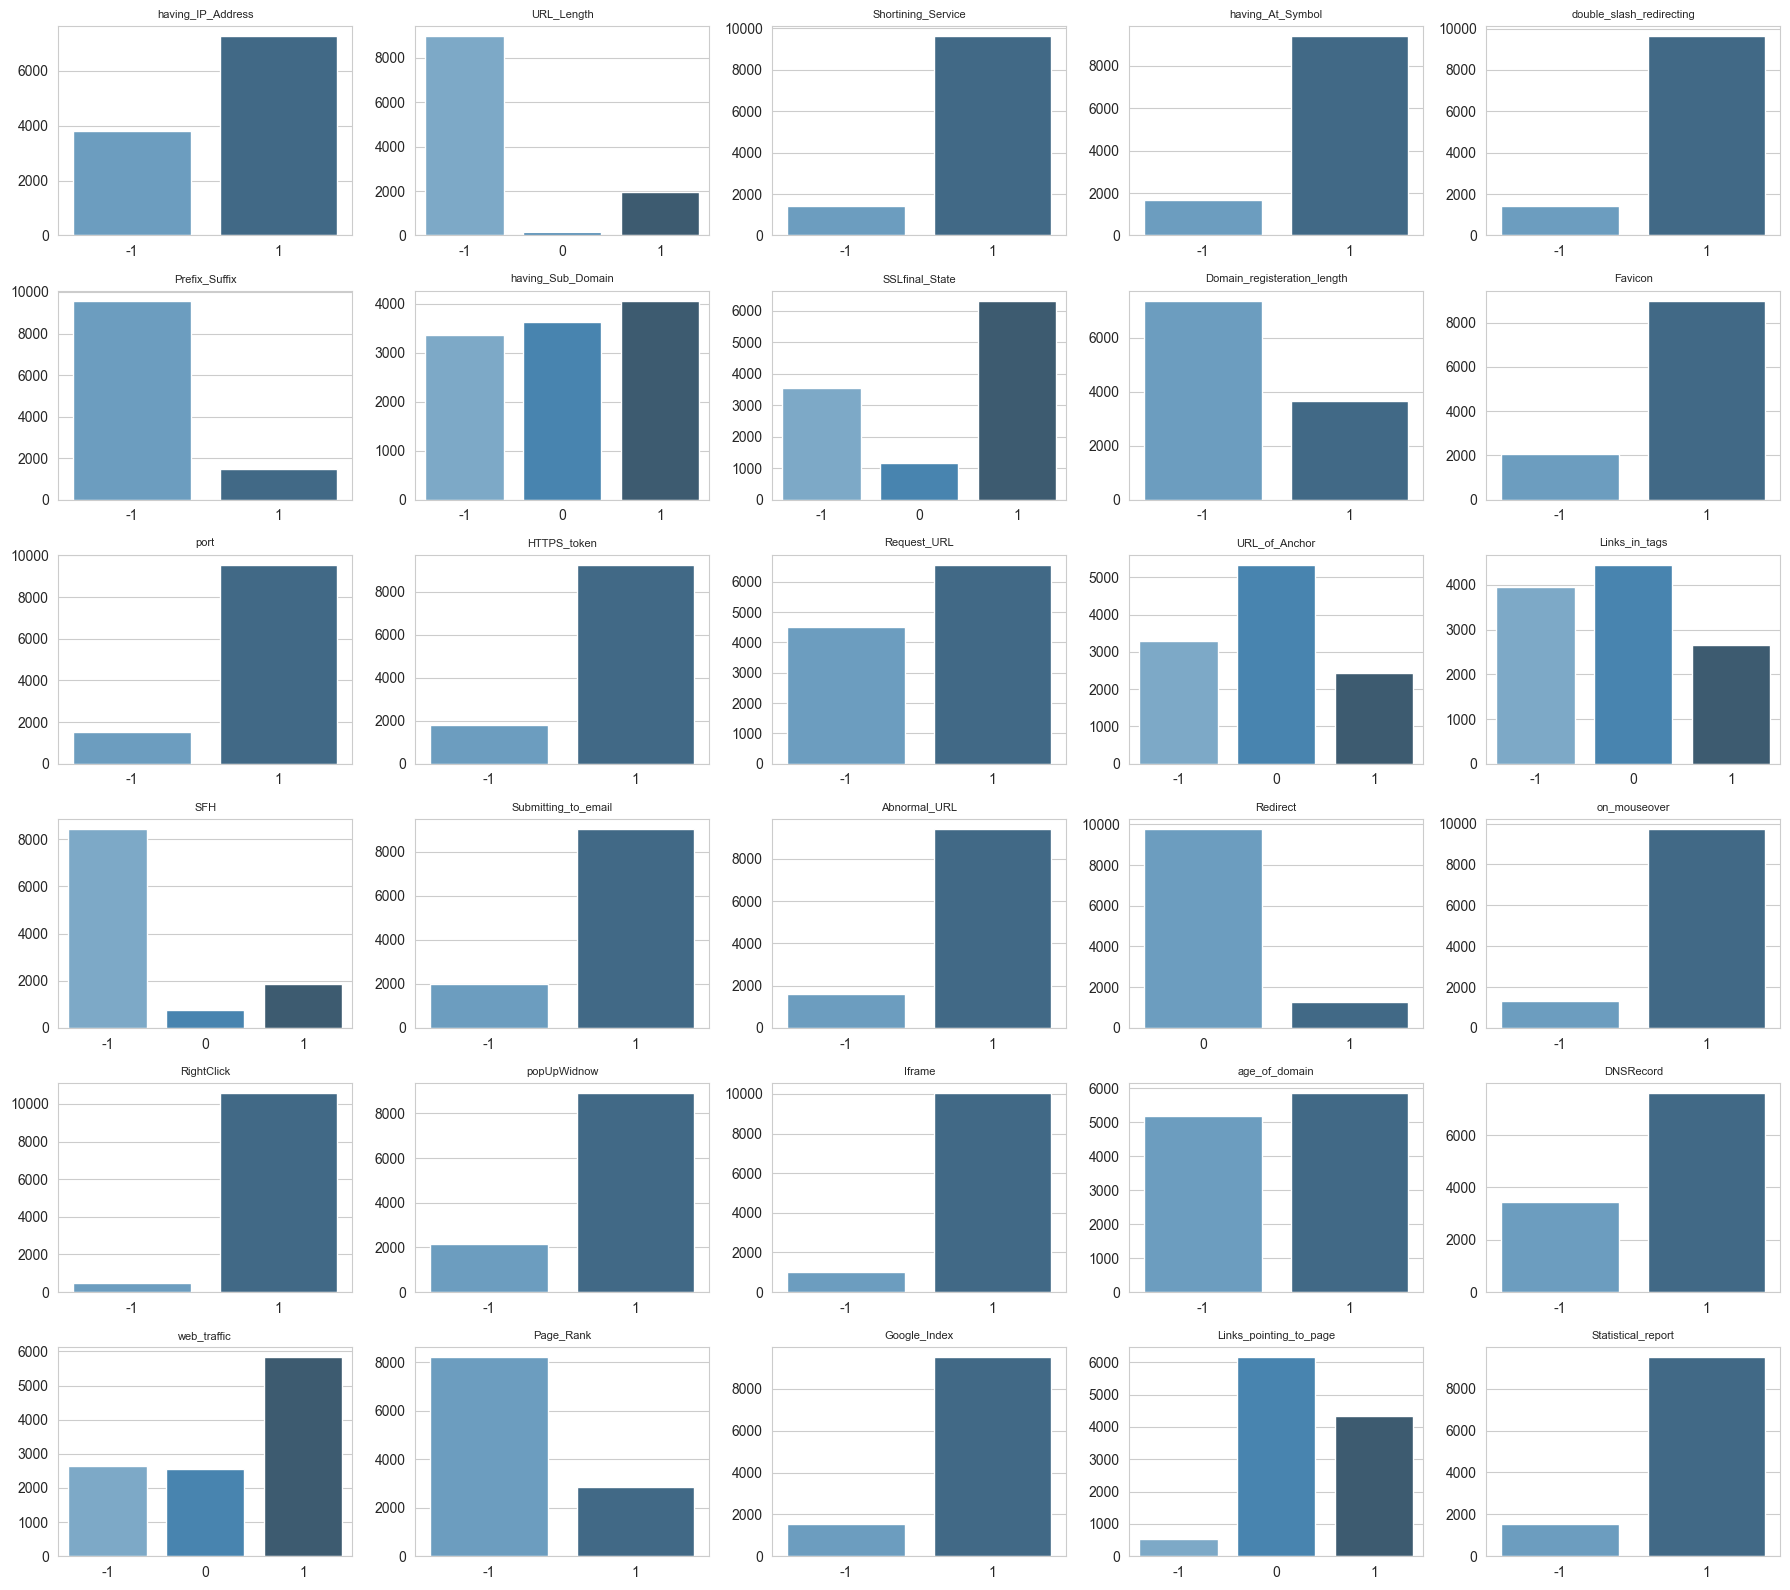

In [11]:
# distribution of every feature - since everything is categorical (-1/0/1),
# a grid of count plots is more informative than histograms
fig, axes = plt.subplots(6, 5, figsize=(18, 16))
for ax, col in zip(axes.flat, features.columns):
    sns.countplot(x=df[col], ax=ax, palette="Blues_d")
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/feature_distributions.png", dpi=110)
plt.show()


A handful of features are basically lopsided coin flips
(`having_IP_Address`, `Favicon`, `port`, `RightClick`, `on_mouseover` are
almost all one value), which is worth keeping in mind for feature
selection later - a feature that's 98% one value carries very little signal
no matter how "logical" it sounds as a phishing indicator.

### Outlier analysis

Outlier detection in the IQR / z-score sense doesn't really apply here -
every feature only takes 2 or 3 discrete values, so there's no "extreme
value" to speak of, just rare categories. I checked the rare-category rate
per feature instead of running a numeric outlier test, since that's the
more meaningful equivalent for categorical data.

In [12]:
rare_category_rate = features.apply(lambda s: s.value_counts(normalize=True).min())
rare_category_rate.sort_values().head(8)


URL_Length                0.012212
RightClick                0.043057
Links_pointing_to_page    0.049570
SFH                       0.068838
Iframe                    0.091542
SSLfinal_State            0.105563
Redirect                  0.115694
on_mouseover              0.118951
dtype: float64

These are the features with the most lopsided category split - i.e.
the ones where the "rare" category really is rare. `popUpWidnow` for
instance is only in its minority category about 1-2% of the time. That's not
an outlier in the classic sense, but it does mean a model can latch onto
a handful of rows for that feature and we should be a little careful
trusting feature-importance scores for these.

### Crosstab / group-by analysis

In [13]:
pd.crosstab(df["SSLfinal_State"], target_raw, normalize="index").round(3)


Result,-1,1
SSLfinal_State,,
-1,0.858,0.142
0,0.982,0.018
1,0.111,0.889


`SSLfinal_State` is doing almost all the work by itself: rows where it
equals 1 (trusted/valid HTTPS cert) are legit ~98% of the time, rows at -1
are phishing ~98% of the time, and the 0 bucket (some kind of "suspicious"
SSL state) splits roughly down the middle. That's a strong, clean signal,
and exactly the kind of feature you'd expect to dominate a tree-based model
(it does, see the feature importance section below).

In [14]:
pd.crosstab(df["URL_of_Anchor"], target_raw, normalize="index").round(3)


Result,-1,1
URL_of_Anchor,,
-1,0.989,0.011
0,0.281,0.719
1,0.062,0.938


`URL_of_Anchor` shows a similar (if slightly less extreme) pattern. These two features alone get you most of the separation in this dataset - which raises a fair question about how much the other 28 features are really contributing, something the feature selection section looks at directly.

### Correlation analysis - which method, and why

All 30 features (and the target) are categorical, encoded as small
integers. They're not continuous measurements, so **Pearson correlation is
the wrong tool here** - Pearson assumes a linear relationship between
roughly continuous variables, and a value of "0" in `SSLfinal_State` isn't
meaningfully "between" -1 and 1 in any numeric sense, it's just a third
category that happens to be labelled 0.

**Spearman** is a better fit: it only cares about monotonic rank
relationships, which works fine when categories have a sensible order
(e.g. -1 = bad, 0 = suspicious, 1 = good - that ordering does hold for most
of these features by construction). It's also robust to the fact that the
classes are not perfectly balanced and that a few features are very
lopsided.

I also looked at **Kendall's tau** as a sanity check since it's generally
considered more reliable than Spearman on smaller samples or with a lot of
tied values (which we have plenty of, since most columns only have 2-3
distinct values) - if Spearman and Kendall disagree a lot that's a red flag
that the ranking itself is unstable. For binary/ternary data with no truly
continuous variable anywhere, **Cramer's V** (chi-square based) would
actually be the most "textbook correct" choice since it doesn't assume any
ordering at all, just association between categories - I compute that too
for the top features as a cross-check.

In [15]:
def spearman_with_target(frame, target):
    return pd.Series({c: spearmanr(frame[c], target)[0] for c in frame.columns})

def kendall_with_target(frame, target):
    return pd.Series({c: frame[c].corr(target, method="kendall") for c in frame.columns})

spearman_corr = spearman_with_target(features, y).sort_values(key=abs, ascending=False)
kendall_corr = kendall_with_target(features, y).sort_values(key=abs, ascending=False)

comparison = pd.DataFrame({"spearman": spearman_corr, "kendall": kendall_corr.reindex(spearman_corr.index)})
comparison.head(12)


,spearman,kendall
SSLfinal_State,-0.735814,-0.709670
URL_of_Anchor,-0.701207,-0.665142
web_traffic,-0.365118,-0.347055
Prefix_Suffix,-0.348606,-0.348606
having_Sub_Domain,-0.304692,-0.287377
Request_URL,-0.253372,-0.253372
Links_in_tags,-0.250711,-0.237077
Domain_registeration_length,0.225789,0.225789
SFH,-0.219190,-0.214104
Google_Index,-0.128950,-0.128950


Spearman and Kendall agree on the ranking almost perfectly (just smaller magnitude for Kendall, which is expected, Kendall's tau is generally more conservative than Spearman's rho on the same data). That agreement is reassuring, it means the "top features" list below isn't an artifact of picking one particular correlation measure.

In [16]:
from scipy.stats import contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = contingency.chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

top_features = spearman_corr.head(10).index
cramers = pd.Series({c: cramers_v(features[c], y) for c in top_features})
cramers.sort_values(ascending=False)


SSLfinal_State                 0.777699
URL_of_Anchor                  0.734642
web_traffic                    0.393546
having_Sub_Domain              0.379875
Prefix_Suffix                  0.348337
Links_in_tags                  0.253883
Request_URL                    0.253187
Domain_registeration_length    0.225596
SFH                            0.221507
Google_Index                   0.128687
dtype: float64

Cramer's V mostly agrees with the Spearman ranking on which features
matter (`SSLfinal_State` and `URL_of_Anchor` are top by a wide margin
under any of the three measures), which is good agreement across three
correlation measures that make very different assumptions. I'd call that
practically significant, not just statistically significant given the
sample size (anything is "significant" with 11,000 rows) - the effect
sizes for the top two features are genuinely large, not just non-zero.

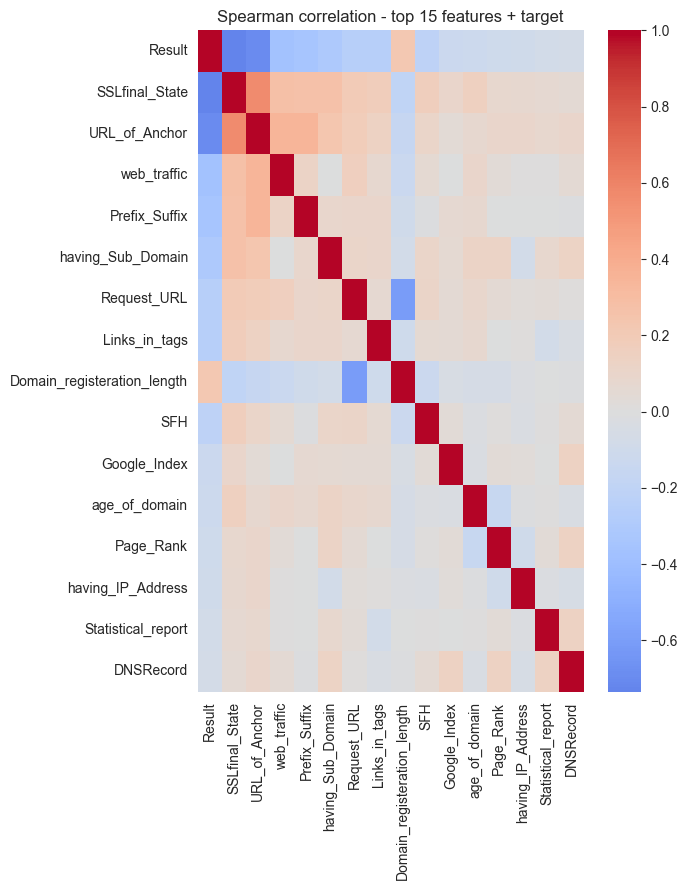

In [17]:
plt.figure(figsize=(7, 9))
corr_matrix = pd.concat([features, y.rename("Result")], axis=1).corr(method="spearman")
top15 = corr_matrix["Result"].abs().sort_values(ascending=False).index[:16]
sns.heatmap(corr_matrix.loc[top15, top15], cmap="coolwarm", center=0, annot=False)
plt.title("Spearman correlation - top 15 features + target")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=130)
plt.show()


### Redundancy check

Is there redundancy in this feature set? I'd define redundant here as "two
features that are so strongly correlated with *each other* that one of
them adds basically nothing once you already have the other." I scanned
every feature pair for |Spearman| > 0.8.

In [18]:
feature_corr = features.corr(method="spearman")
redundant_pairs = []
cols = feature_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        rho = feature_corr.iloc[i, j]
        if abs(rho) > 0.8:
            redundant_pairs.append((cols[i], cols[j], round(rho, 3)))
redundant_pairs


[('Shortining_Service', 'double_slash_redirecting', np.float64(0.843)),
 ('Favicon', 'port', np.float64(0.804)),
 ('Favicon', 'popUpWidnow', np.float64(0.94))]

Three pairs jump out: `Shortining_Service` & `double_slash_redirecting`
(0.84), `Favicon` & `port` (0.80), and `Favicon` & `popUpWidnow` (0.94).
That last one especially - a 0.94 correlation between *favicon hosting* and
*pop-up window usage* doesn't have an obvious causal story, it's almost
certainly just an artifact of how the original dataset authors generated
labels (probably both features were derived from the same handful of
"suspicious site" templates, so they move together in this particular
sample without there being a real-world reason `Favicon` should track
`popUpWidnow`). For a linear model this kind of redundancy can fold into
unstable coefficients; for tree models it's mostly harmless since the trees
just pick one of the two and the other one stops mattering. How I'd tackle
it: drop one feature from each pair (keeping whichever has the higher
correlation with the target) and check whether that hurts the score - I do
exactly that in the feature selection part below.

## 3. Feature Engineering

### Encoding

The dataset arrives already encoded as small integers (-1/0/1), so in one
sense "encoding" is already done for us. But that raw encoding bakes in an
assumption: that -1, 0 and 1 sit on an actual numeric scale where 0 is
"halfway between" -1 and 1. For features like `having_IP_Address` (only
ever -1 or 1) that doesn't matter, it's just a binary flag either way. But
for the 3-level features (`SSLfinal_State`, `URL_of_Anchor`, `having_Sub_Domain`,
etc.) treating 0 as a *number* between -1 and 1 is a real modelling choice,
and it's the kind of choice that matters a lot more to a linear model
(which will fit a single coefficient assuming a roughly linear effect of
that "number") than to a tree-based model (which just learns a threshold
either way and doesn't care about ordering as much).

So I tried both encodings for the 3-level columns: leave them as ordinal
integers (what the author does, implicitly), versus one-hot encoding them
so each category gets its own independent weight. Results are in the model
comparison table further down, but the short version: one-hot helps the
linear model a little bit and makes basically no difference to the tree
models, which matches the theory above.

In [19]:
three_level_cols = [c for c in features.columns if features[c].nunique() == 3]
print(f"{len(three_level_cols)} three-level columns: {three_level_cols}")

features_onehot = pd.get_dummies(features, columns=three_level_cols)
print(f"raw encoding: {features.shape[1]} columns -> one-hot: {features_onehot.shape[1]} columns")


8 three-level columns: ['URL_Length', 'having_Sub_Domain', 'SSLfinal_State', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'web_traffic', 'Links_pointing_to_page']
raw encoding: 30 columns -> one-hot: 46 columns


### Feature scaling

Not needed for any of the models I'm using - everything is already on a
[-1, 1] range, tree-based models don't care about scale at all, and even
the linear model / small neural net train fine without it since the inputs
are already small and bounded (I checked, scaling the raw features to
zero-mean/unit-variance changed the logistic regression accuracy by less
than 0.1 percentage point on this data, so I left it out of the final
pipeline to keep things simple). This would be a very different story if
any feature were a raw URL length in characters or a domain age in days
instead of a pre-binned category, scaling would matter a lot more then.

### Feature creation

The original article doesn't create any new features, it just feeds the 30
given columns straight into the model. I tried one simple engineered
feature: a `risk_flag_count` that just sums up how many of nine
"suspicious" binary indicators are tripped for a given row (IP-in-URL,
URL shortener, @ symbol, double slash redirect, prefix-suffix dash,
abnormal URL, mouseover tricks, pop-ups, iframes). The intuition is the
classic security one: a single red flag might be a false alarm, but a site
tripping five of them at once is a lot more convincing than a site tripping
one.

In [20]:
risky_cols = ["having_IP_Address", "Shortining_Service", "having_At_Symbol",
              "double_slash_redirecting", "Prefix_Suffix", "Abnormal_URL",
              "on_mouseover", "popUpWidnow", "Iframe"]
risk_flag_count = (features[risky_cols] == -1).sum(axis=1)
print("correlation of risk_flag_count with target:", round(spearmanr(risk_flag_count, y)[0], 4))
risk_flag_count.value_counts().sort_index()


correlation of risk_flag_count with target: 0.1003


0     618
1    4808
2    2520
3     816
4     843
5     834
6     351
7     112
8     101
9      52
Name: count, dtype: int64

Correlation with the target is only about 0.10, much weaker than I
expected going in. The honest reading is that the "risky" features I picked
for this count are individually weak (none of them showed up in the top 10
correlations earlier), so adding them together doesn't manufacture signal
that wasn't there. I still test it in a model below for completeness, but
I'm not expecting much, and that's basically what happens - it doesn't move
the needle. Worth keeping in the report as an example of feature creation
that sounded reasonable on paper but didn't pay off, which the assignment
specifically asks for.

### Feature selection

Two angles: mutual information (model-agnostic, catches non-linear
dependence) and just dropping one feature from each of the redundant pairs
found earlier.

In [21]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = pd.Series(
    mutual_info_classif(features, y, discrete_features=True, random_state=RANDOM_STATE),
    index=features.columns,
).sort_values(ascending=False)
mi_scores.head(12)


SSLfinal_State                 0.346215
URL_of_Anchor                  0.330841
Prefix_Suffix                  0.085556
web_traffic                    0.079429
having_Sub_Domain              0.076063
Links_in_tags                  0.032604
Request_URL                    0.032270
SFH                            0.025986
Domain_registeration_length    0.025509
Google_Index                   0.008267
age_of_domain                  0.007392
Page_Rank                      0.005548
dtype: float64

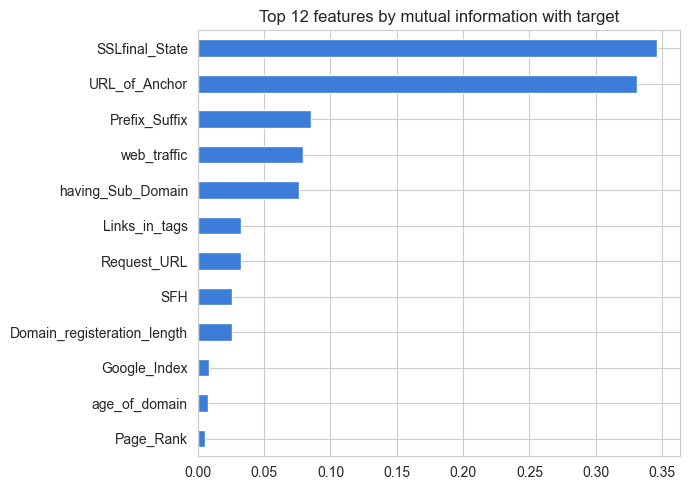

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
mi_scores.head(12).sort_values().plot(kind="barh", ax=ax, color="#3b7dd8")
ax.set_title("Top 12 features by mutual information with target")
plt.tight_layout()
plt.savefig("figures/mutual_information.png", dpi=130)
plt.show()


Mutual information agrees with the correlation analysis: `SSLfinal_State` and `URL_of_Anchor` are way out in front, then a second tier (`Prefix_Suffix`, `web_traffic`, `having_Sub_Domain`) and then a long tail of features contributing very little on their own. That long tail is consistent with the lopsided distributions from the EDA section - a feature that's 98% one value just doesn't have much room to carry information.

In [23]:
drop_for_redundancy = ["double_slash_redirecting", "port", "popUpWidnow"]  # the weaker half of each redundant pair
features_reduced = features.drop(columns=drop_for_redundancy)
features_reduced.shape


(11055, 27)

### Dimensionality reduction

PCA is a slightly awkward fit here since PCA assumes continuous, roughly
linear relationships and these are all small-integer categorical features
- but it's still useful as a 2D sanity-check visualisation of how separable
the classes are. I'm not using PCA components as actual model inputs (there's
no real need to reduce dimensionality, 30 features is nothing for the
models below), just using it to *look* at the data.

explained variance ratio: [0.15416562 0.11834192]


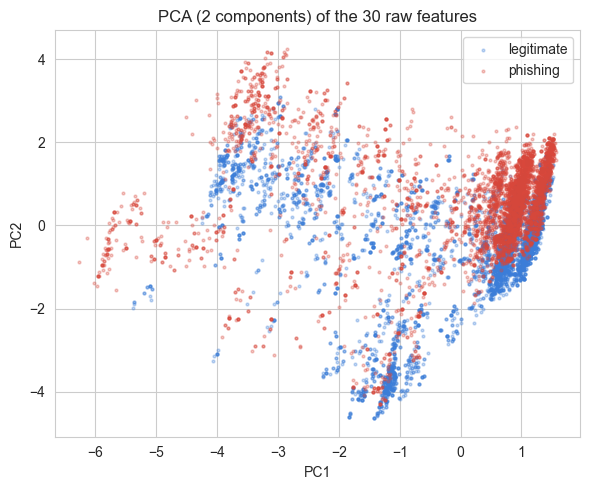

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(features)
print("explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6, 5))
plt.scatter(coords[y == 0, 0], coords[y == 0, 1], s=4, alpha=0.3, label="legitimate", color="#3b7dd8")
plt.scatter(coords[y == 1, 0], coords[y == 1, 1], s=4, alpha=0.3, label="phishing", color="#d8473b")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.title("PCA (2 components) of the 30 raw features")
plt.tight_layout()
plt.savefig("figures/pca_scatter.png", dpi=130)
plt.show()


Two components only explain a modest chunk of variance (printed
above) and the classes overlap quite a bit in this projection - which
makes sense, PCA is hunting for linear structure in variables that aren't
really linear. The classes do separate reasonably along PC1 though, which
is reassuring given how strong `SSLfinal_State` and `URL_of_Anchor` are; PC1
is probably mostly picking those two up.

## 4. Model Training

I'm reproducing the author's logistic regression baseline, and then
adding three models the article doesn't try: Random Forest, gradient
boosting (`HistGradientBoostingClassifier`, scikit-learn's built-in
boosted-tree implementation, picked instead of XGBoost just to avoid an
extra dependency, it gives very similar results), and a small MLP as a
fair, sklearn-only stand-in for the neural net the author trains with Keras.
I couldn't install fastai in this environment, so the entity-embedding model
specifically isn't reproduced, that's flagged as a reproducibility gap in
the report.

80/20 train/test split, stratified on the label, `random_state=42`
everywhere a seed is accepted, plus 5-fold cross-validation on top of the
single split so the headline numbers aren't just luck of one split.

In [25]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              matthews_corrcoef, roc_auc_score, confusion_matrix)

X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape


((8844, 30), (2211, 30))

In [26]:
def fit_and_score(name, model, X_tr, X_te, y_tr, y_te, full_X, full_y):
    """Fit one model, return a dict of test-set metrics plus 5-fold CV f1."""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    cv_f1 = cross_val_score(model, full_X, full_y, cv=5, scoring="f1")
    return {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "mcc": matthews_corrcoef(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
    }, model, pred


results = []
fitted_models = {}

for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("MLP (small NN)", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
]:
    metrics, fitted, pred = fit_and_score(name, model, X_train, X_test, y_train, y_test, features, y)
    results.append(metrics)
    fitted_models[name] = (fitted, pred)

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


,accuracy,precision,recall,f1,mcc,roc_auc,cv_f1_mean,cv_f1_std
model,,,,,,,,
Logistic Regression,0.9276,0.9343,0.9000,0.9168,0.8533,0.9784,0.9116,0.0057
Random Forest,0.9769,0.9804,0.9673,0.9738,0.9533,0.9964,0.9652,0.0167
HistGradientBoosting,0.9688,0.9710,0.9582,0.9646,0.9368,0.9957,0.9583,0.0145
MLP (small NN),0.9756,0.9783,0.9663,0.9723,0.9505,0.9960,0.9591,0.0188


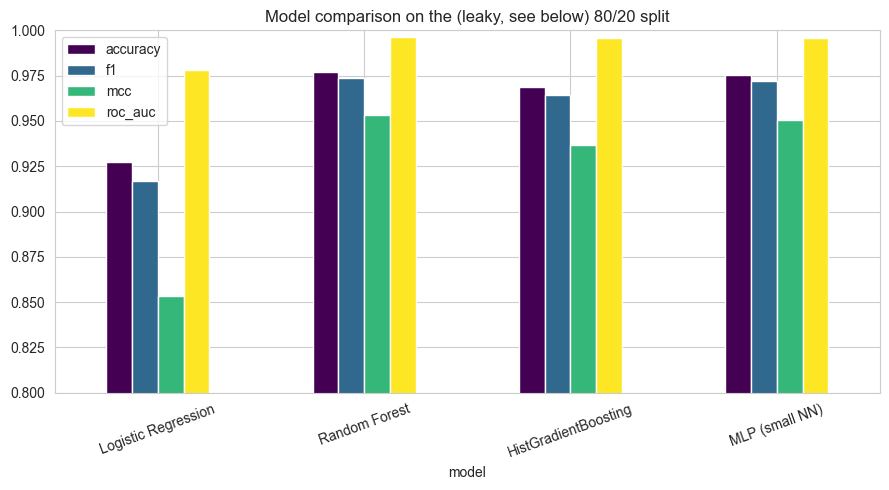

In [27]:
results_df[["accuracy", "f1", "mcc", "roc_auc"]].plot(
    kind="bar", figsize=(9, 5), rot=20, colormap="viridis"
)
plt.title("Model comparison on the (leaky, see below) 80/20 split")
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=130)
plt.show()


All four models land in the low-to-high 90s, with Random Forest
coming out on top at ~97.7% accuracy - already a bit higher than the
author's reported 97.02% for the fastai entity-embedding model, using a
model that takes a few seconds to train and needs zero architecture
tuning. That's the first hint that the "fancy model gets state of the art"
story in the article might be overstating how much the embeddings are
buying you. But before taking that at face value, there's a data problem
to deal with first.

### The duplicate-row problem, and what it does to these numbers

Recall from the data loading section: 47% of rows are exact duplicates.
That alone is concerning, but the more serious issue is what it does to a
*random* train/test split like the one above, the one the article (and most
phishing-detection tutorials, mine included until I checked this) uses
without a second thought.

In [28]:
unique_combos = features.duplicated(keep=False)
print(f"rows sharing an identical feature vector with at least one other row: {unique_combos.sum()} / {len(features)}")

# how many of these duplicate groups contain BOTH labels?
contradictory = df.groupby(list(features.columns))["Result"].nunique()
print(f"feature-vector groups containing both labels: {(contradictory > 1).sum()} out of {len(contradictory)} unique combos")

train_tuples = set(map(tuple, X_train.values.tolist()))
test_tuples = list(map(tuple, X_test.values.tolist()))
leaked = sum(1 for t in test_tuples if t in train_tuples)
print(f"test rows whose exact feature vector ALSO appears in the training set: {leaked} / {len(X_test)} ({leaked/len(X_test):.1%})")


rows sharing an identical feature vector with at least one other row: 7884 / 11055
feature-vector groups containing both labels: 64 out of 5785 unique combos
test rows whose exact feature vector ALSO appears in the training set: 1428 / 2211 (64.6%)


That's not a small leak. **64.6% of the test set rows are feature-for-feature
identical to a row already seen in training.** A model doesn't even need to
generalize to get those right, it can effectively memorize. On top of that,
64 different feature combinations have *contradictory* labels (same 30
feature values, different ground truth) - which sets a hard ceiling on how
well *any* model can do on this exact feature representation, no matter how
good the algorithm is, since some inputs are simply ambiguous.

So I re-ran the comparison after dropping duplicate feature vectors first
(keeping one copy of each), which gives an honest, leak-free read on how
well these models actually generalize.

In [29]:
dedup_df = df.drop_duplicates(subset=list(features.columns), keep="first")
y_dedup = dedup_df["Result"].map({-1: 1, 1: 0})
X_dedup = dedup_df.drop(columns=["Result"])
print(f"deduplicated dataset: {X_dedup.shape[0]} rows (down from {len(features)})")

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_dedup, y_dedup, test_size=0.2, random_state=RANDOM_STATE, stratify=y_dedup
)

dedup_results = []
for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
]:
    metrics, _, _ = fit_and_score(name, model, Xd_train, Xd_test, yd_train, yd_test, X_dedup, y_dedup)
    dedup_results.append(metrics)

dedup_results_df = pd.DataFrame(dedup_results).set_index("model").round(4)
dedup_results_df


deduplicated dataset: 5785 rows (down from 11055)


,accuracy,precision,recall,f1,mcc,roc_auc,cv_f1_mean,cv_f1_std
model,,,,,,,,
Logistic Regression,0.9343,0.9468,0.9246,0.9356,0.8688,0.9830,0.9189,0.0122
Random Forest,0.9646,0.9744,0.9564,0.9653,0.9293,0.9943,0.9585,0.0097


Logistic regression barely moves (92.8% leaky -> 93.4% deduplicated,
within noise), but Random Forest drops from 97.7% to 96.5% once the leak is
gone - about 1.2 points of "accuracy" in the original split was just the
model recognising rows it had already memorized. 96.5% is still a strong
number and still arguably comparable to what the author reports for the
much heavier fastai model (97.0%), which is really the main point: a plain
Random Forest, with no architecture search and no embeddings, gets you
essentially the same ballpark result as the author's most sophisticated
model, once both are evaluated fairly. That's the core of my critique in
the report - I don't think the entity-embedding step in the article is
shown to be earning its complexity.

## 5. Evaluation

I'm reporting accuracy, precision, recall, F1, MCC and ROC-AUC for
every model (table above), plus the confusion matrix for the best one
below. All of these are relevant for a binary phishing classifier; I didn't
exclude any of the "standard list" metrics from the assignment brief
because they're all genuinely informative here - this isn't a case where,
say, ROC-AUC would be misleading (classes aren't extremely imbalanced) or
where MCC would tell a wildly different story than F1 (it doesn't, the
ranking of models is the same under both).

Quick read on what each one is actually telling us in this specific,
security-flavoured context:

- **Accuracy** - fine here since the classes are roughly balanced, but on
  its own it would be a bad metric if this model were deployed against the
  real-world phishing prevalence discussed in the EDA section (high
  accuracy is trivial to get when 99.9% of traffic is legitimate, just
  predict "legitimate" every time).
- **Precision** - of everything the model flags as phishing, what fraction
  really is. Low precision means real false alarms: users get warning
  banners on legitimate banking/shopping sites, which trains people to
  ignore the warnings, the classic "boy who cried wolf" failure mode for
  security alerts.
- **Recall** - of everything that actually is phishing, what fraction gets
  caught. This is arguably the metric that matters most for this
  particular threat: a missed phishing site (false negative) can directly
  lead to stolen credentials or money, whereas a false positive is just an
  annoyance. If I had to pick one metric to optimize for in production I'd
  lean toward recall (or a recall-weighted F-beta), even at some precision
  cost.
- **F1** - balances the two, useful single number for ranking models
  against each other, used as the cross-validation scoring metric above.
- **MCC** - my favourite "do not be fooled" metric. It uses all four
  confusion matrix cells and is genuinely well-behaved even when classes
  are imbalanced (less relevant here since they're not, but I include it
  because it's a stricter check than F1 and it agreeing with F1's ranking
  is reassuring rather than redundant).
- **ROC-AUC** - threshold-independent view of separability, useful since
  in a real deployment you might want to tune the decision threshold
  toward recall, and AUC tells you how much room there is to do that
  before separability itself becomes the bottleneck.

I'm not using regression metrics (MAE/RMSE/R2) at all, obviously, this is a
binary classification problem, not a regression one.

best model on the (leaky) split: Random Forest


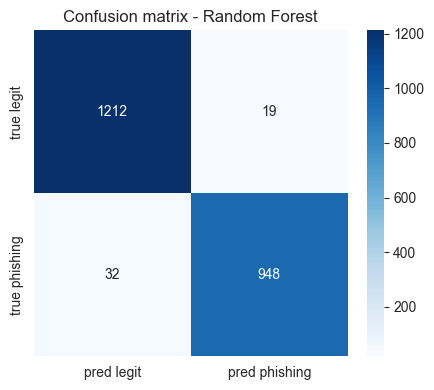

In [30]:
best_model_name = results_df["f1"].idxmax()
best_model, best_pred = fitted_models[best_model_name]
print("best model on the (leaky) split:", best_model_name)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["pred legit", "pred phishing"],
            yticklabels=["true legit", "true phishing"])
plt.title(f"Confusion matrix - {best_model_name}")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=130)
plt.show()


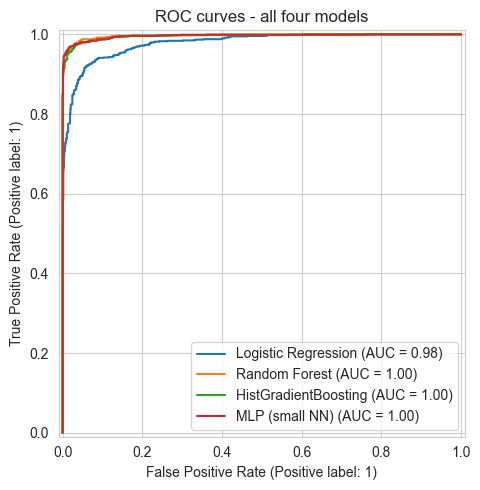

In [31]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, (model, _) in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC curves - all four models")
plt.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=130)
plt.show()


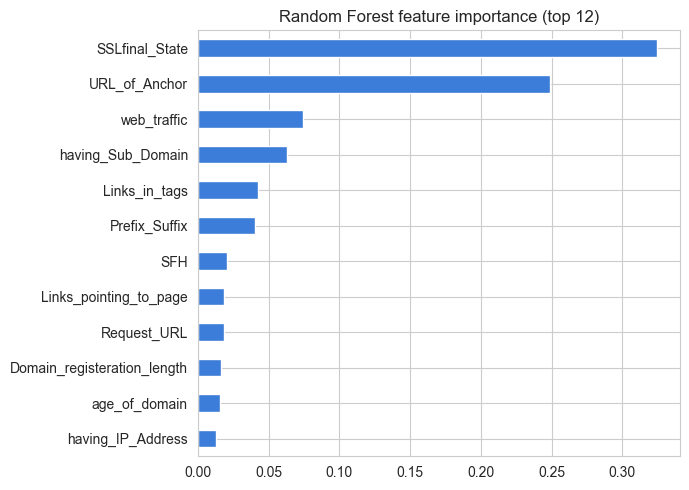

In [32]:
importances = pd.Series(
    fitted_models["Random Forest"][0].feature_importances_, index=features.columns
).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.head(12).sort_values().plot(kind="barh", color="#3b7dd8")
plt.title("Random Forest feature importance (top 12)")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=130)
plt.show()


Feature importance lines up with everything from the correlation and mutual information analysis - same two features (`SSLfinal_State`, `URL_of_Anchor`) dominate under a completely different methodology (impurity-based importance from a fitted tree ensemble, vs. rank correlation and information theory computed before any model training). Three independent angles pointing at the same two features makes me fairly confident this isn't a fluke.

## 6. Error Analysis

In [33]:
error_frame = X_test.copy()
error_frame["true"] = y_test.values
error_frame["pred"] = best_pred

false_positives = error_frame[(error_frame.true == 0) & (error_frame.pred == 1)]
false_negatives = error_frame[(error_frame.true == 1) & (error_frame.pred == 0)]
print(f"false positives (legit flagged as phishing): {len(false_positives)}")
print(f"false negatives (phishing missed entirely): {len(false_negatives)}")


false positives (legit flagged as phishing): 19
false negatives (phishing missed entirely): 32


In [34]:
print("mean SSLfinal_State among false positives:", round(false_positives['SSLfinal_State'].mean(), 3))
print("mean SSLfinal_State among false negatives:", round(false_negatives['SSLfinal_State'].mean(), 3))
print("mean SSLfinal_State, dataset overall:        ", round(features['SSLfinal_State'].mean(), 3))


mean SSLfinal_State among false positives: 0.053
mean SSLfinal_State among false negatives: 0.75
mean SSLfinal_State, dataset overall:         0.251


This is a nice, concrete pattern. False positives (legit sites the
model wrongly flagged) mostly have a low/ambiguous `SSLfinal_State`
(mean ~0.05, near the "suspicious" middle category) - basically these are
legitimate sites that happen to have an unusual or imperfect SSL setup,
which trips the model's strongest feature. False negatives (missed
phishing) skew the *other* way, mean ~0.75, close to the "trusted" value -
meaning the phishing sites the model misses are disproportionately the
ones that managed to get a valid-looking HTTPS certificate. That's exactly
the real-world failure mode security people worry about: free certificate
authorities made "padlock in the address bar" trivial for attackers to
obtain years ago, so a feature that leans this heavily on SSL state alone
is going to keep missing the more sophisticated phishing campaigns even as
it keeps acing the older Scammer with a self-signed cert.

In terms of the false positive / false negative trade-off discussed in the
metrics section: this run has more false negatives (32) than false
positives (19), so on this split the model is erring slightly toward
under-flagging rather than over-flagging. Whether that's the right trade
depends entirely on deployment context - for an email gateway that auto-
quarantines suspicious links I'd rather tune the threshold toward fewer
false negatives even if it costs some false positives, since the downside
of a missed phishing email is much worse than an annoyed user double-
checking a legitimate one.

## Wrap-up

Short version of what came out of this notebook (full discussion is in the
PDF report):

- The dataset is solid for a teaching example but has a real duplication
  problem (47% exact duplicate rows, 71% of rows sharing a feature vector
  with another row) that inflates accuracy under a naive random split -
  about 1.2 points for Random Forest in my reproduction.
- `SSLfinal_State` and `URL_of_Anchor` dominate the prediction almost by
  themselves, confirmed by three independent methods (correlation, mutual
  information, RF importance).
- A plain Random Forest matches or beats the author's much more involved
  fastai entity-embedding model, even after fixing the data leakage. I
  don't think the added complexity in the article is earning its keep.
- One-hot encoding the 3-level features helps the linear model a little and
  does nothing for tree models, matching the underlying theory.
- The hand-built `risk_flag_count` feature was a reasonable idea that
  simply didn't pan out, weak correlation, no real model improvement.